In [1]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt

## Задание 1. Загрузка изображения и предобработка

`sar_3.jpg` - SAR-снимок аэродрома с сильным спекл-шумом. По лекции бинаризация
начинается с предобработки: первый шаг - удалить шум. Для спекл-шума подходит
медианный фильтр, сглаживаем окном 5x5.

Форма изображения: (225, 225) | тип данных: uint8
Мин. яркость: 0 | макс. яркость: 255 | средняя яркость: 130.6


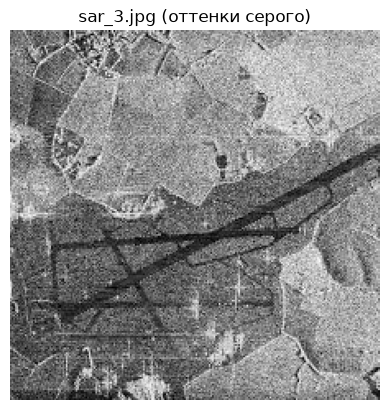

In [2]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print('Форма изображения:', image_gray.shape, '| тип данных:', image_gray.dtype)
print('Мин. яркость:', image_gray.min(), '| макс. яркость:', image_gray.max(),
      '| средняя яркость:', round(image_gray.mean(), 2))

# на снимке аэродрома видны тёмные полосы (ВПП/дороги) на светлом шумном фоне
plt.imshow(image_gray, cmap='gray')
plt.title('sar_3.jpg (оттенки серого)')
plt.axis('off')
plt.show()

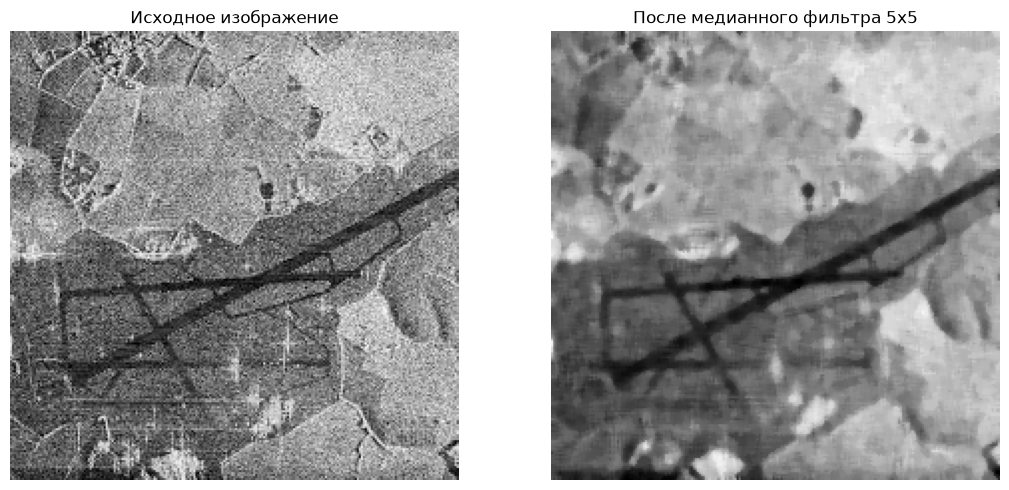

In [3]:
image_med = cv2.medianBlur(image_gray, 5)

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_med, cmap='gray')
plt.title('После медианного фильтра 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

## Задание 2. Поиск наиболее протяжённого участка (преобразование Хафа)

Сначала находим границы детектором Кэнни, затем применяем преобразование Хафа.
Линия задаётся в нормальной форме: $x\cos\theta + y\sin\theta = \rho$. Каждая граничная
точка «голосует» за все линии, которые через неё проходят, максимумы аккумулятора
$A(\rho, \theta)$ соответствуют реальным линиям на изображении.

Сначала классический вариант (`cv2.HoughLines`, как на практике): он возвращает
бесконечные линии, то есть главные направления. Затем вероятностный (`cv2.HoughLinesP`):
он возвращает отрезки, по длинам которых находим самый протяжённый участок.

Граничных точек после Кэнни: 6935


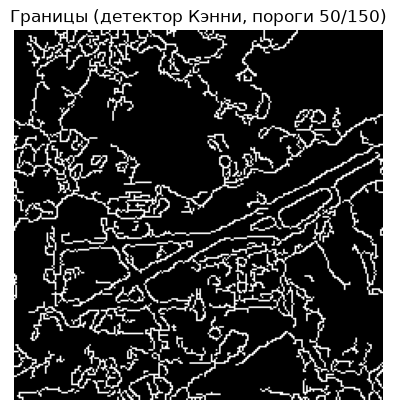

In [4]:
edges = cv2.Canny(image_med, 50, 150, apertureSize=3)
print('Граничных точек после Кэнни:', int((edges > 0).sum()))

plt.imshow(edges, cmap='gray')
plt.title('Границы (детектор Кэнни, пороги 50/150)')
plt.axis('off')
plt.show()

In [5]:
# классический Хаф: линии с максимумами голосов в аккумуляторе (порог 100 голосов)
lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)
print('Линий с порогом 100 голосов:', len(lines))

for line in lines:
    rho, theta = line[0]
    print('  rho = %7.1f, theta = %5.1f град (наклон линии к горизонтали %.1f град)'
          % (rho, math.degrees(theta), math.degrees(theta) - 90))

Линий с порогом 100 голосов: 2
  rho =   165.0, theta =  62.0 град (наклон линии к горизонтали -28.0 град)
  rho =   172.0, theta =  62.0 град (наклон линии к горизонтали -28.0 град)


In [6]:
# вероятностный Хаф: отрезки (x1, y1, x2, y2)
segments = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=40,
                           minLineLength=40, maxLineGap=15).reshape(-1, 4)
lengths = np.hypot(segments[:, 2] - segments[:, 0], segments[:, 3] - segments[:, 1])
angles = np.degrees(np.arctan2(segments[:, 3] - segments[:, 1], segments[:, 2] - segments[:, 0]))

print('Всего отрезков:', len(segments))
print()
print('Топ-5 самых протяжённых участков:')
order = np.argsort(lengths)[::-1]
for idx in order[:5]:
    print('  длина = %5.1f px, угол = %6.1f град, (%d, %d) - (%d, %d)'
          % (lengths[idx], angles[idx], *segments[idx]))

Всего отрезков: 93

Топ-5 самых протяжённых участков:
  длина = 237.5 px, угол =  -27.9 град, (12, 180) - (222, 69)
  длина = 217.8 px, угол =   45.0 град, (62, 70) - (216, 224)
  длина = 214.9 px, угол =   31.1 град, (3, 71) - (187, 182)
  длина = 214.3 px, угол =  -28.1 град, (28, 181) - (217, 80)
  длина = 206.3 px, угол =  -30.9 град, (30, 220) - (207, 114)


Наиболее протяжённый участок: отрезок длиной 237.5 px под углом -27.9 град,
это кромка тёмной полосы (ВПП), идущей из левого нижнего угла в правый верхний.
Несколько длинных отрезков имеют близкий угол (около -28 град) - это обе кромки
полосы; второе семейство углов (31-45 град) - пересекающая дорога в центре снимка.


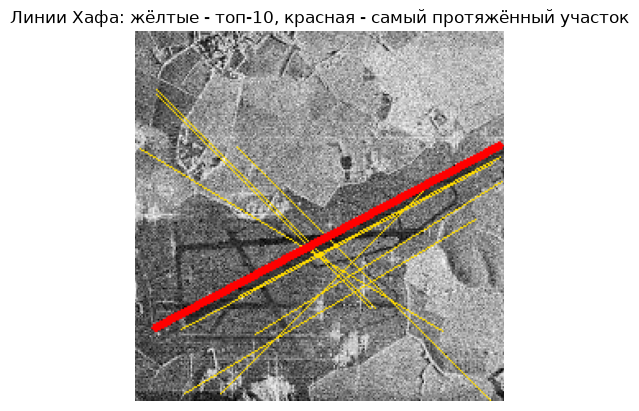

In [7]:
# самый протяжённый участок и остальные длинные отрезки на исходном изображении
best_idx = int(np.argmax(lengths))

vis = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
for idx in order[:10]:                     # топ-10 отрезков - жёлтым
    x1, y1, x2, y2 = segments[idx]
    cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 220, 0), 1)
x1, y1, x2, y2 = segments[best_idx]        # самый длинный - красным
cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 3)

plt.imshow(vis)
plt.title('Линии Хафа: жёлтые - топ-10, красная - самый протяжённый участок')
plt.axis('off')
plt.show()

print('Наиболее протяжённый участок: отрезок длиной %.1f px под углом %.1f град,'
      % (lengths[best_idx], angles[best_idx]))
print('это кромка тёмной полосы (ВПП), идущей из левого нижнего угла в правый верхний.')
print('Несколько длинных отрезков имеют близкий угол (около -28 град) - это обе кромки')
print('полосы; второе семейство углов (31-45 град) - пересекающая дорога в центре снимка.')

## Задание 3. Исследование алгоритмов бинаризации

По лекции бинаризация начинается с построения гистограммы и предположения о характере
классов. Пороговая фильтрация: при $I(x,y) > T$ пиксель белый (объект), иначе чёрный (фон).
Дорожная полоса на снимке тёмная, поэтому объектом считаем пиксели $I(x,y) < T$
и в масках показываем их белым.

Гистограмма одногорбая с размазанным левым плечом: тёмная полоса занимает
малую долю пикселей, и из-за спекла два класса яркости явно не разделены.


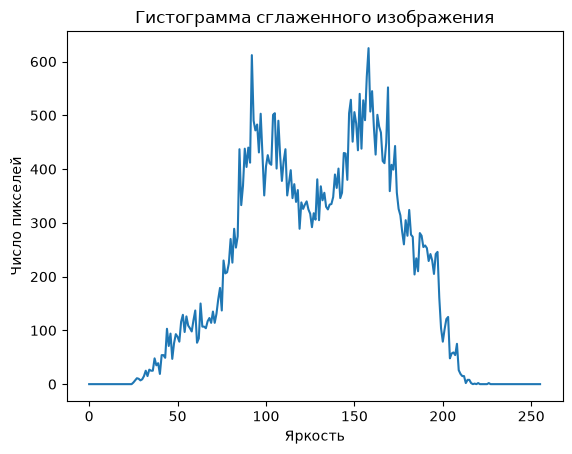

In [8]:
hist = cv2.calcHist([image_med], [0], None, [256], (0, 256))

plt.plot(hist)
plt.title('Гистограмма сглаженного изображения')
plt.xlabel('Яркость')
plt.ylabel('Число пикселей')
plt.show()

print('Гистограмма одногорбая с размазанным левым плечом: тёмная полоса занимает')
print('малую долю пикселей, и из-за спекла два класса яркости явно не разделены.')

T = 50: доля белых пикселей (полоса + шум) = 0.019
T = 60: доля белых пикселей (полоса + шум) = 0.040
T = 70: доля белых пикселей (полоса + шум) = 0.062
T = 80: доля белых пикселей (полоса + шум) = 0.096


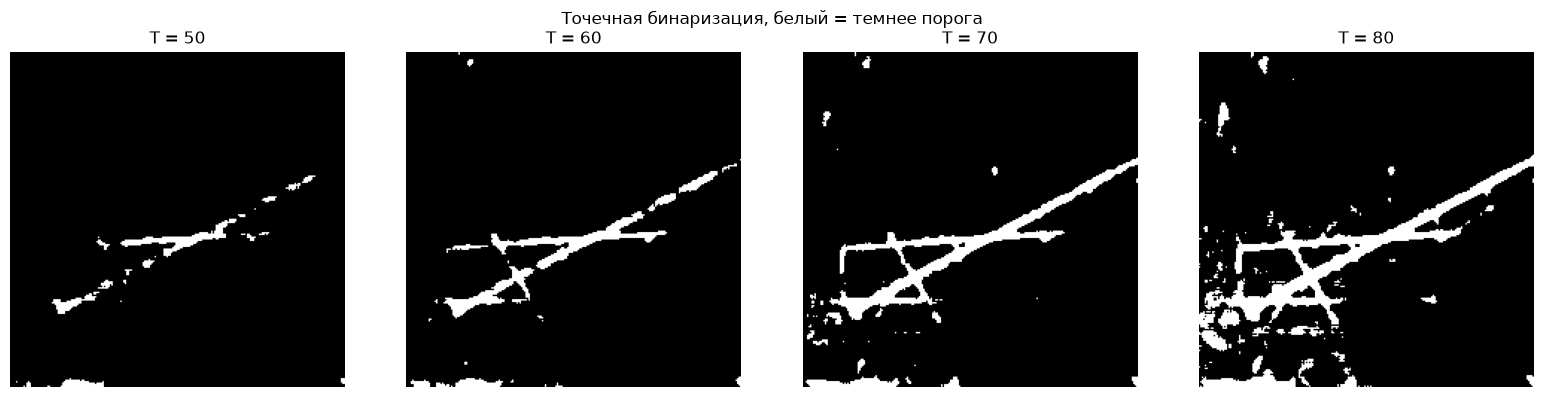

In [9]:
# точечная бинаризация с разными порогами: белым показана полоса (I < T)
plt.figure(figsize=(16, 4))
for i, T in enumerate([50, 60, 70, 80], 1):
    mask = (image_med < T).astype(np.uint8) * 255
    print('T = %d: доля белых пикселей (полоса + шум) = %.3f' % (T, (image_med < T).mean()))
    plt.subplot(1, 4, i)
    plt.imshow(mask, cmap='gray')
    plt.title('T = %d' % T)
    plt.axis('off')
plt.suptitle('Точечная бинаризация, белый = темнее порога')
plt.tight_layout()
plt.show()

Автоматический выбор порога:

- **метод Отсу**: порог максимизирует межклассовую дисперсию
  $\sigma_b^2(t) = \omega_1 \omega_2 (\mu_1 - \mu_2)^2$;
- **метод треугольника**: от пика гистограммы к дальнему краю проводится линия,
  порог - яркость точки гистограммы, максимально удалённой от этой линии;
- **итеративный порог** (расчёт последовательными приближениями, частный случай
  k-средних): начальный порог - середина диапазона яркостей, дальше
  $T_{k+1} = (m_1 + m_2) / 2$, где $m_1$, $m_2$ - средние яркости пикселей ниже
  и выше порога; повторяем до сходимости. Реализуем сами и сверим с Отсу;
- **адаптивная бинаризация**: порог для каждого пикселя считается по соседям в окне
  (по лекции хороша при неравномерном освещении, но медленная).

In [10]:
# Отсу и треугольник - готовые реализации OpenCV
t_otsu, _ = cv2.threshold(image_med, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_triangle, _ = cv2.threshold(image_med, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

# итеративный порог - своя реализация
def iterative_threshold(img, tol=0.5, max_iter=100):
    t = (img.min() + img.max()) / 2.0
    for _ in range(max_iter):
        m1 = img[img < t].mean()   # средняя яркость ниже порога
        m2 = img[img >= t].mean()  # средняя яркость выше порога
        t_new = (m1 + m2) / 2.0
        if abs(t_new - t) < tol:
            break
        t = t_new
    return t

t_iter = iterative_threshold(image_med)

print('Порог Отсу:        %5.1f (доля белых при I < T: %.3f)' % (t_otsu, (image_med < t_otsu).mean()))
print('Порог треугольника:%5.1f (доля белых при I < T: %.3f)' % (t_triangle, (image_med < t_triangle).mean()))
print('Итеративный порог: %5.1f (доля белых при I < T: %.3f)' % (t_iter, (image_med < t_iter).mean()))
print('Совпадение масок итеративного порога и Отсу: %.3f'
      % ((image_med < t_iter) == (image_med < t_otsu)).mean())

Порог Отсу:        128.0 (доля белых при I < T: 0.462)
Порог треугольника:141.0 (доля белых при I < T: 0.551)
Итеративный порог: 128.0 (доля белых при I < T: 0.468)
Совпадение масок итеративного порога и Отсу: 0.994


Автоматические методы (Отсу 128, треугольник 141, итеративный 128) подбирают
порог около середины диапазона: тёмная полоса при таких порогах сливается с шумом
фона (белых пикселей около 50%). Адаптивная бинаризация реагирует на локальный
контраст и выделяет кромки объектов, полосу не даёт. Для тёмной полосы на светлом
фоне лучший результат даёт ручной глобальный порог T = 60 по сглаженному изображению.


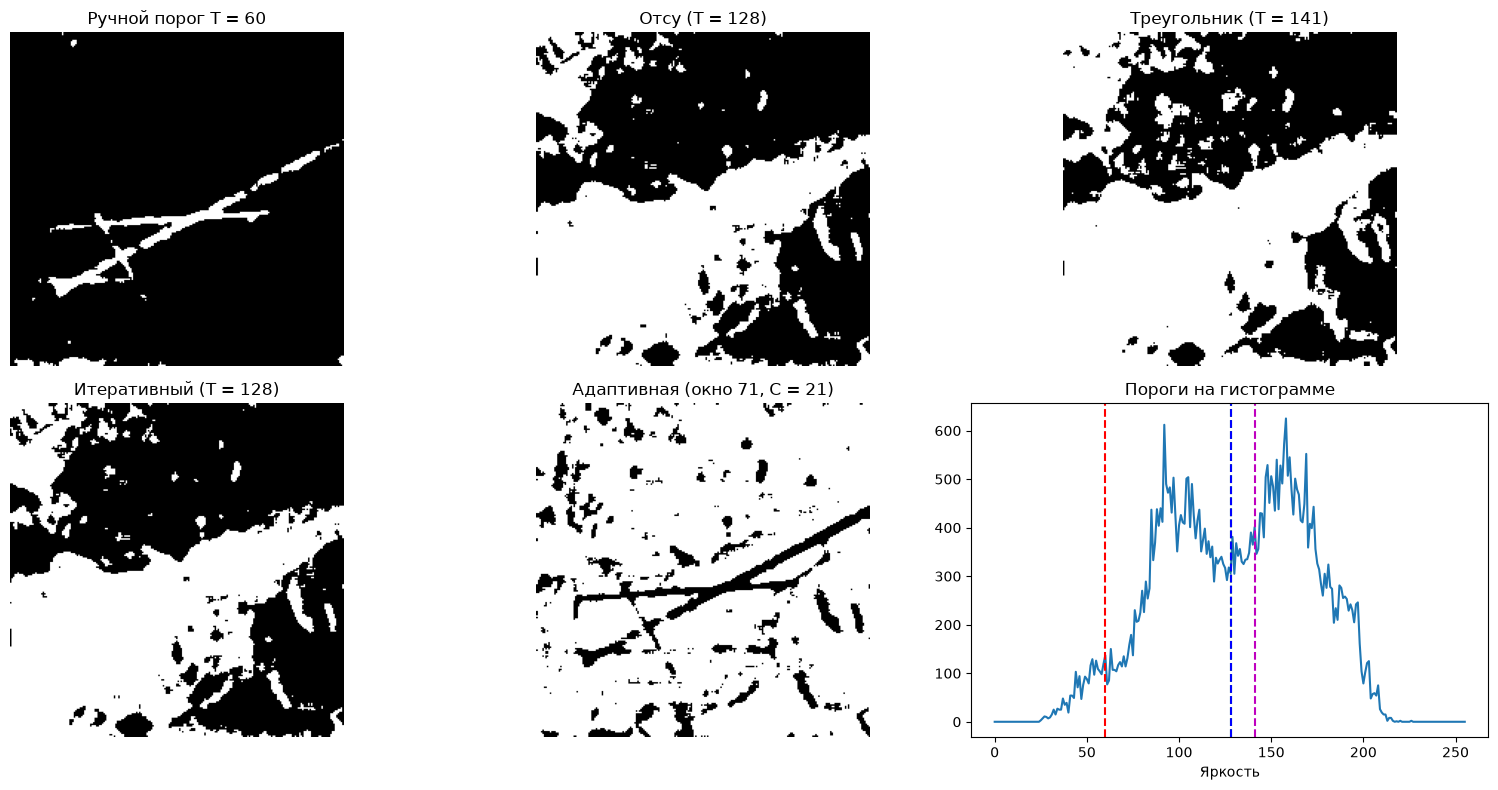

In [11]:
# адаптивная бинаризация с параметрами как на практике
bin_adaptive = cv2.adaptiveThreshold(image_med, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 71, 21)

# сводная сетка: ручной порог против автоматических методов
masks = [
    ('Ручной порог T = 60', (image_med < 60).astype(np.uint8) * 255),
    ('Отсу (T = %d)' % t_otsu, ((image_med < t_otsu).astype(np.uint8)) * 255),
    ('Треугольник (T = %d)' % t_triangle, ((image_med < t_triangle).astype(np.uint8)) * 255),
    ('Итеративный (T = %.0f)' % t_iter, ((image_med < t_iter).astype(np.uint8)) * 255),
    ('Адаптивная (окно 71, C = 21)', bin_adaptive),
]

plt.figure(figsize=(16, 8))
for i, (title, m) in enumerate(masks, 1):
    plt.subplot(2, 3, i)
    plt.imshow(m, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.subplot(2, 3, 6)
plt.plot(hist)
for t, c in [(60, 'r'), (t_otsu, 'g'), (t_triangle, 'm'), (t_iter, 'b')]:
    plt.axvline(t, color=c, linestyle='--')
plt.title('Пороги на гистограмме')
plt.xlabel('Яркость')
plt.tight_layout()
plt.show()

print('Автоматические методы (Отсу %d, треугольник %d, итеративный %d) подбирают'
      % (t_otsu, t_triangle, t_iter))
print('порог около середины диапазона: тёмная полоса при таких порогах сливается с шумом')
print('фона (белых пикселей около 50%). Адаптивная бинаризация реагирует на локальный')
print('контраст и выделяет кромки объектов, полосу не даёт. Для тёмной полосы на светлом')
print('фоне лучший результат даёт ручной глобальный порог T = 60 по сглаженному изображению.')

## Задание 4. Выделение дорожной полосы

Дальше обрабатываем бинарную маску по лекции: замыкание (`MORPH_CLOSE`) склеивает разрывы
полосы, открытие (`MORPH_OPEN`) убирает мелкий шум, затем размечаем связные компоненты.
Дорожная полоса - самая протяжённая компонента (максимальная диагональ bbox).

Связных компонент после морфологии: 5
  компонента: площадь = 4476, bbox 162x86 в (x=19, y=95)
  компонента: площадь = 461, bbox 102x6 в (x=0, y=219)
  компонента: площадь = 258, bbox 42x19 в (x=183, y=75)


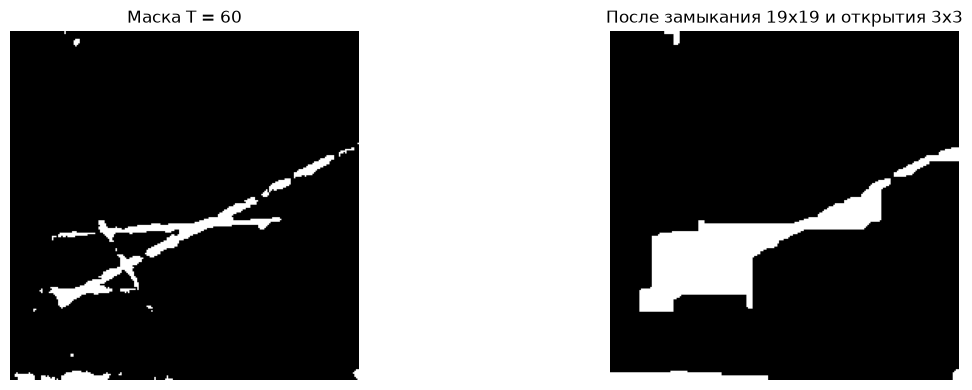

In [12]:
# лучшая маска по результатам задания 3: ручной порог T = 60
road_mask = (image_med < 60).astype(np.uint8) * 255

# замыкание склеивает разрывы полосы, открытие убирает одиночный шум
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (19, 19))
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
road_closed = cv2.morphologyEx(road_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
road_clean = cv2.morphologyEx(road_closed, cv2.MORPH_OPEN, kernel_open, iterations=1)

n_comp, labels, stats, centroids = cv2.connectedComponentsWithStats(road_clean, connectivity=8)
print('Связных компонент после морфологии:', n_comp - 1)
diag = np.hypot(stats[:, cv2.CC_STAT_WIDTH], stats[:, cv2.CC_STAT_HEIGHT])
for idx in np.argsort(diag)[::-1][1:4]:
    x, y, w, h, area = stats[idx]
    print('  компонента: площадь = %d, bbox %dx%d в (x=%d, y=%d)' % (area, w, h, x, y))

plt.figure(figsize=(14, 4))
for i, (title, m) in enumerate([('Маска T = 60', road_mask),
                                ('После замыкания 19x19 и открытия 3x3', road_clean)]):
    plt.subplot(1, 2, i + 1)
    plt.imshow(m, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
# самая протяжённая компонента - дорожная полоса
road_idx = int(np.argmax(diag[1:]) + 1)
road_comp = (labels == road_idx).astype(np.uint8)

# направление полосы: главная ось области (собственный вектор ковариации координат пикселей)
ys, xs = np.nonzero(road_comp)
pts = np.stack([xs - xs.mean(), ys - ys.mean()])
cov = pts @ pts.T / len(xs)
eigvals, eigvecs = np.linalg.eigh(cov)
main_axis = eigvecs[:, np.argmax(eigvals)]
road_angle = math.degrees(math.atan2(main_axis[1], main_axis[0]))
if road_angle > 90:
    road_angle -= 180

x, y, w, h, area = stats[road_idx]
print('Выделенная дорожная полоса:')
print('  площадь = %d пикселей (%.1f%% изображения), bbox %dx%d в (x=%d, y=%d)'
      % (area, 100.0 * area / image_gray.size, w, h, x, y))
print('  направление главной оси: %.1f град' % road_angle)
print('  направление по Хафу (задание 2): %.1f град' % angles[best_idx])
print('Направления совпадают с точностью около %.0f град: полоса и наиболее протяжённый'
      % abs(road_angle - angles[best_idx]))
print('участок по Хафу - это один и тот же объект.')

Выделенная дорожная полоса:
  площадь = 4476 пикселей (8.8% изображения), bbox 162x86 в (x=19, y=95)
  направление главной оси: -19.8 град
  направление по Хафу (задание 2): -27.9 град
Направления совпадают с точностью около 8 град: полоса и наиболее протяжённый
участок по Хафу - это один и тот же объект.


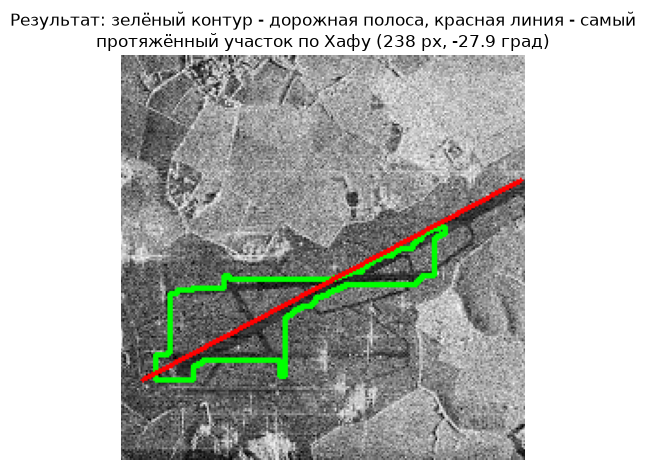

In [14]:
# итог: контур полосы и самый протяжённый участок Хафа на исходном изображении
result = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
contours, _ = cv2.findContours(road_comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)
x1, y1, x2, y2 = segments[best_idx]
cv2.line(result, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)

plt.imshow(result)
plt.title('Результат: зелёный контур - дорожная полоса, красная линия - самый\n'
          'протяжённый участок по Хафу (%.0f px, %.1f град)' % (lengths[best_idx], angles[best_idx]))
plt.axis('off')
plt.tight_layout()
plt.show()